In [1]:
# import the libraries
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings 
warnings.filterwarnings("ignore")

In [3]:
data = {
    "text": [
        "where is my order",
        "track my order",
        "cancel my order",
        "i want refund",
        "payment failed",
        "late delivery",
        "cannot login",
        "product details",
        "i have complaint",
        "hello",
        "order not delivered",
        "refund my money",
        "login problem",
        "delivery is late",
        "hi",
        "cancel it now",
        "need product info",
        "payment not working",
        "complaint about service",
        "where is shipment"
    ],
    "intent": [
        "order_status",
        "order_status",
        "cancel_order",
        "refund_request",
        "payment_issue",
        "delivery_delay",
        "login_issue",
        "product_query",
        "complaint",
        "greeting",
        "order_status",
        "refund_request",
        "login_issue",
        "delivery_delay",
        "greeting",
        "cancel_order",
        "product_query",
        "payment_issue",
        "complaint",
        "order_status"
    ]
}
df = pd.DataFrame(data)
df.head()

,text,intent
0,where is my order,order_status
1,track my order,order_status
2,cancel my order,cancel_order
3,i want refund,refund_request
4,payment failed,payment_issue


In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["intent"], test_size=0.2, random_state=42)

In [5]:
# Vectorization 
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [6]:
# Train the model 
model = LogisticRegression()
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
# Predictions 
y_pred = model.predict(X_test_vec)
y_pred

array(['order_status', 'order_status', 'greeting', 'order_status'],
      dtype=object)

In [8]:
# Evaluation Metrics 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5

Classification Report:

               precision    recall  f1-score   support

 cancel_order       0.00      0.00      0.00         1
     greeting       0.00      0.00      0.00         0
 order_status       0.67      1.00      0.80         2
payment_issue       0.00      0.00      0.00         1

     accuracy                           0.50         4
    macro avg       0.17      0.25      0.20         4
 weighted avg       0.33      0.50      0.40         4



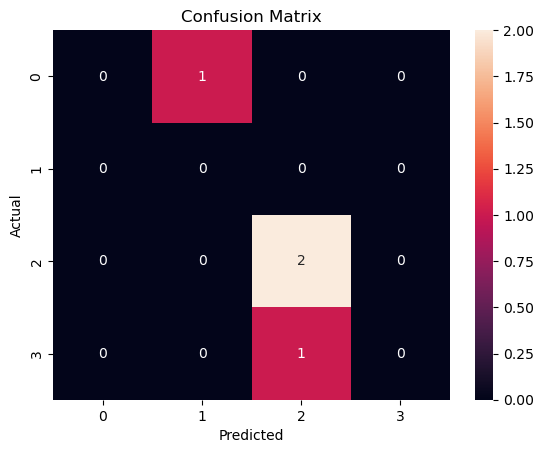

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [10]:
# Add Confidence Score
probs = model.predict_proba(X_test_vec)
confidence = probs.max(axis=1)
print(probs)

[[0.09090915 0.10077728 0.11366224 0.10611435 0.09949536 0.20861385
  0.0581375  0.10077728 0.12151299]
 [0.06046565 0.11303031 0.10389249 0.1196116  0.11145895 0.16837457
  0.09869802 0.11303031 0.1114381 ]
 [0.11176816 0.11849154 0.10860048 0.12565065 0.11678667 0.12064937
  0.06470308 0.11849154 0.1148585 ]
 [0.11861224 0.10687711 0.09865924 0.11275728 0.10546828 0.14850966
  0.06073229 0.10687711 0.14150679]]


In [11]:
print(confidence)

[0.20861385 0.16837457 0.12565065 0.14850966]


In [12]:
# Create final prediction
def predict_intent_with_confidence(text):
    x = vectorizer.transform([text])
    probs = model.predict_proba(x)
    intent = model.predict(x)[0]
    confidence = probs.max()
    return intent, confidence

In [13]:
# Add Response System
responses = {
    "order_status": "Your order is on the way.",
    "cancel_order": "Your order has been cancelled.",
    "refund_request": "Your refund will be processed soon.",
    "payment_issue": "Please check your payment details.",
    "delivery_delay": "We apologize for the delay.",
    "login_issue": "Please reset your password.",
    "product_query": "Please check product description.",
    "complaint": "We have registered your complaint.",
    "greeting": "Hello! How can I help you?"
}
def generate_response(intent, confidence):
    if confidence < 0.2:
        return "Sorry, I didn't understand. Could you please repeat?"
    return responses.get(intent, "Sorry, I didn’t understand.")

In [14]:
# Test Text-based chatbot
user_input = input("Enter your query: ")
intent, conf = predict_intent_with_confidence(user_input)
response = generate_response(intent, conf)
print("Intent:", intent)
print("Confidence:", conf)
print("Response:", response)

Enter your query:  where is my order 


Intent: order_status
Confidence: 0.20861385196315868
Response: Your order is on the way.


In [15]:
# Add Voice
import whisper
asr_model = whisper.load_model("base")

In [16]:
pip install numpy==2.1.0

Note: you may need to restart the kernel to use updated packages.


In [17]:
print(np.__version__)

2.1.0


In [18]:
# Speech to text
def speech_to_text(audio_path):
    result = asr_model.transcribe(audio_path)
    return result["text"]

In [19]:
# Text to Speech 
from gtts import gTTS
def text_to_speech(text):
    tts = gTTS(text=text)
    tts.save("output.mp3")

In [20]:
# Full voice test
audio = r"C:\Users\syams\Intern Project\input.m4a"
text = speech_to_text(audio)
print("User said:", text)
intent, conf = predict_intent_with_confidence(text)
print("Intent:", intent, "Confidence:", conf)
response = generate_response(intent, conf)
print("Bot:", response)
text_to_speech(response)
print("Audio saved as output.mp3")

User said:  I want a refund.
Intent: refund_request Confidence: 0.2934844940189405
Bot: Your refund will be processed soon.
Audio saved as output.mp3


In [21]:
import os 
print(os.getcwd())

C:\Users\syams\Intern Project


In [22]:
import os 
print(os.listdir())

['.ipynb_checkpoints', 'input.m4a', 'output.mp3', 'Untitled.ipynb']


In [23]:
audio = r"C:\Users\syams\Intern Project\input.m4a"
import os
print("Exists:", os.path.exists(audio))
text = speech_to_text(audio)
print("User said:", text)

Exists: True
User said:  I want a refund.


In [24]:
import os
os.system("ffmpeg -version")

0

In [25]:
text = speech_to_text(audio)
print("User said:", text)

User said:  I want a refund.


In [26]:
audio = r"C:\Users\syams\Intern Project\input.m4a"
text = speech_to_text(audio)
print("User said:", text)

User said:  I want a refund.


In [27]:
import whisper
asr_model = whisper.load_model("base")
def speech_to_text(audio_path):
    result = asr_model.transcribe(audio_path)
    return result["text"]

In [1]:
from IPython.display import Audio
Audio("output.mp3")